In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D, Concatenate, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import numpy as np
import pandas as pd

In [2]:
import os

IMAGE_SIZE = 256
IMAGE_DIR = r"C:\Users\jash1\OneDrive\Desktop\sem 7\dl_app\image_segmentation\archive (12)\Image"
MASK_DIR = r"C:\Users\jash1\OneDrive\Desktop\sem 7\dl_app\image_segmentation\archive (12)\Mask"

def load_images(image_dir, mask_dir):
    images = []
    masks = []
    
    # Get the file names without extensions for comparison
    image_names = [os.path.splitext(f)[0] for f in os.listdir(image_dir)]
    mask_names = [os.path.splitext(f)[0] for f in os.listdir(mask_dir)]
    
    # Use only those files that have both image and mask
    common_files = set(image_names).intersection(mask_names)
    
    for file_name in common_files:
        image_path = os.path.join(image_dir, file_name + ".jpg")  # Change extension if needed
        mask_path = os.path.join(mask_dir, file_name + ".png")    # Change extension if needed
        
        print(f"Loading image: {image_path}")
        print(f"Loading mask: {mask_path}")
        
        image = cv2.imread(image_path)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        # Check if image or mask failed to load
        if image is None:
            print(f"Failed to load image: {image_path}")
            continue
        if mask is None:
            print(f"Failed to load mask: {mask_path}")
            continue
        
        # Resize to a consistent size
        image = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE))
        mask = cv2.resize(mask, (IMAGE_SIZE, IMAGE_SIZE))
        
        # Normalize images to [0, 1]
        image = image / 255.0
        mask = mask / 255.0
        
        images.append(image)
        masks.append(mask)
    
    return np.array(images), np.array(masks)

# Load images and masks
images, masks = load_images(IMAGE_DIR, MASK_DIR)

# Debugging prints to ensure data is loaded
print(f"Loaded {len(images)} images.")
print(f"Loaded {len(masks)} masks.")

# Proceed with train-test split if data is successfully loaded
if len(images) == 0 or len(masks) == 0:
    print("No images or masks were loaded, please check the paths or dataset.")
else:
    X_train, X_test, y_train, y_test = train_test_split(images, masks, test_size=0.2, random_state=42)


Loading image: C:\Users\jash1\OneDrive\Desktop\sem 7\dl_app\image_segmentation\archive (12)\Image\2048.jpg
Loading mask: C:\Users\jash1\OneDrive\Desktop\sem 7\dl_app\image_segmentation\archive (12)\Mask\2048.png
Loading image: C:\Users\jash1\OneDrive\Desktop\sem 7\dl_app\image_segmentation\archive (12)\Image\3045.jpg
Loading mask: C:\Users\jash1\OneDrive\Desktop\sem 7\dl_app\image_segmentation\archive (12)\Mask\3045.png
Loading image: C:\Users\jash1\OneDrive\Desktop\sem 7\dl_app\image_segmentation\archive (12)\Image\5.jpg
Loading mask: C:\Users\jash1\OneDrive\Desktop\sem 7\dl_app\image_segmentation\archive (12)\Mask\5.png
Loading image: C:\Users\jash1\OneDrive\Desktop\sem 7\dl_app\image_segmentation\archive (12)\Image\3039.jpg
Loading mask: C:\Users\jash1\OneDrive\Desktop\sem 7\dl_app\image_segmentation\archive (12)\Mask\3039.png
Loading image: C:\Users\jash1\OneDrive\Desktop\sem 7\dl_app\image_segmentation\archive (12)\Image\31.jpg
Loading mask: C:\Users\jash1\OneDrive\Desktop\sem 7\d

In [3]:
print(os.listdir(IMAGE_DIR))
print(os.listdir(MASK_DIR))


['0.jpg', '1.jpg', '10.jpg', '1000.jpg', '1001.jpg', '1002.jpg', '1003.jpg', '1004.jpg', '1005.jpg', '1006.jpg', '1007.jpg', '1008.jpg', '1009.jpg', '1010.jpg', '1011.jpg', '1012.jpg', '1013.jpg', '1014.jpg', '1015.jpg', '1016.jpg', '1017.jpg', '1018.jpg', '1019.jpg', '1020.jpg', '1021.jpg', '1022.jpg', '1023.jpg', '1024.jpg', '1025.jpg', '1026.jpg', '1027.jpg', '1028.jpg', '1029.jpg', '1030.jpg', '1031.jpg', '1032.jpg', '1033.jpg', '1034.jpg', '1035.jpg', '1036.jpg', '1037.jpg', '1038.jpg', '1039.jpg', '1040.jpg', '1041.jpg', '1042.jpg', '1043.jpg', '1044.jpg', '1045.jpg', '1046.jpg', '1047.jpg', '1048.jpg', '1049.jpg', '1050.jpg', '1051.jpg', '1052.jpg', '1053.jpg', '1054.jpg', '1055.jpg', '1056.jpg', '1057.jpg', '1058.jpg', '1059.jpg', '1060.jpg', '1061.jpg', '1062.jpg', '1063.jpg', '1064.jpg', '1065.jpg', '1066.jpg', '1067.jpg', '1068.jpg', '1069.jpg', '1070.jpg', '1071.jpg', '1072.jpg', '1073.jpg', '1074.jpg', '1075.jpg', '1076.jpg', '1077.jpg', '1078.jpg', '1079.jpg', '1080.jpg',

In [4]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D, Concatenate, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def unet_model(input_size=(256, 256, 3)):
    inputs = Input(input_size)
    
    # Downsampling
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    c2 = Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    c3 = Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = Conv2D(256, (3, 3), activation='relu', padding='same')(c3)
    p3 = MaxPooling2D((2, 2))(c3)

    c4 = Conv2D(512, (3, 3), activation='relu', padding='same')(p3)
    c4 = Conv2D(512, (3, 3), activation='relu', padding='same')(c4)
    p4 = MaxPooling2D(pool_size=(2, 2))(c4)

    # Bottleneck
    c5 = Conv2D(1024, (3, 3), activation='relu', padding='same')(p4)
    c5 = Conv2D(1024, (3, 3), activation='relu', padding='same')(c5)

    # Upsampling
    u6 = UpSampling2D(size=(2, 2))(c5)
    u6 = Concatenate()([u6, c4])
    c6 = Conv2D(512, (3, 3), activation='relu', padding='same')(u6)
    c6 = Conv2D(512, (3, 3), activation='relu', padding='same')(c6)

    u7 = UpSampling2D(size=(2, 2))(c6)
    u7 = Concatenate()([u7, c3])
    c7 = Conv2D(256, (3, 3), activation='relu', padding='same')(u7)
    c7 = Conv2D(256, (3, 3), activation='relu', padding='same')(c7)

    u8 = UpSampling2D(size=(2, 2))(c7)
    u8 = Concatenate()([u8, c2])
    c8 = Conv2D(128, (3, 3), activation='relu', padding='same')(u8)
    c8 = Conv2D(128, (3, 3), activation='relu', padding='same')(c8)

    u9 = UpSampling2D(size=(2, 2))(c8)
    u9 = Concatenate()([u9, c1])
    c9 = Conv2D(64, (3, 3), activation='relu', padding='same')(u9)
    c9 = Conv2D(64, (3, 3), activation='relu', padding='same')(c9)

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c9)

    model = Model(inputs=[inputs], outputs=[outputs])
    return model

# Compile the model
model = unet_model()
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model with dynamic batch size
try:
    history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=25, batch_size=1)
except ValueError as e:
    print(f"Batch size issue: {e}")
    # Adjust batch size if there is an issue
    history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=25, batch_size=8)

Epoch 1/25
231/231 [==============================] - 39s 121ms/step - loss: 0.6606 - accuracy: 0.6581 - val_loss: 0.5208 - val_accuracy: 0.7590
Epoch 2/25
231/231 [==============================] - 27s 119ms/step - loss: 0.5725 - accuracy: 0.7283 - val_loss: 0.5724 - val_accuracy: 0.7204
Epoch 3/25
231/231 [==============================] - 28s 119ms/step - loss: 0.5660 - accuracy: 0.6956 - val_loss: 0.6172 - val_accuracy: 0.5814
Epoch 4/25
231/231 [==============================] - 28s 121ms/step - loss: 0.5896 - accuracy: 0.7019 - val_loss: 0.5597 - val_accuracy: 0.7332
Epoch 5/25
231/231 [==============================] - 28s 122ms/step - loss: 0.5171 - accuracy: 0.7312 - val_loss: 0.4923 - val_accuracy: 0.7607
Epoch 6/25
231/231 [==============================] - 28s 123ms/step - loss: 0.5100 - accuracy: 0.7212 - val_loss: 0.4767 - val_accuracy: 0.7659
Epoch 7/25
231/231 [==============================] - 28s 122ms/step - loss: 0.4863 - accuracy: 0.7532 - val_loss: 0.5030 - val_ac

1/1 [==============================] - 0s 179ms/step


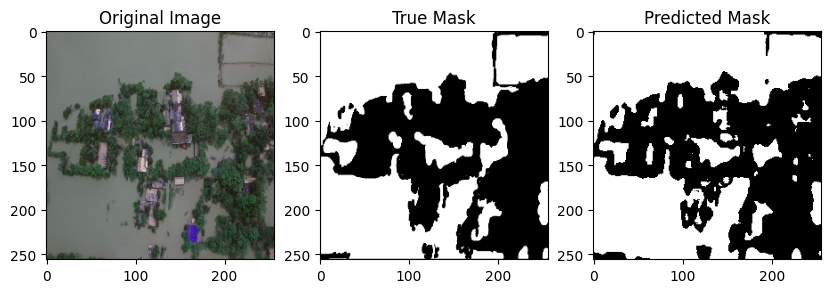

1/1 [==============================] - 0s 21ms/step


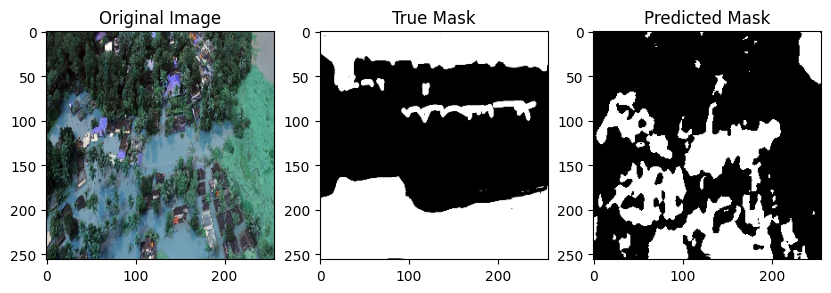

1/1 [==============================] - 0s 21ms/step


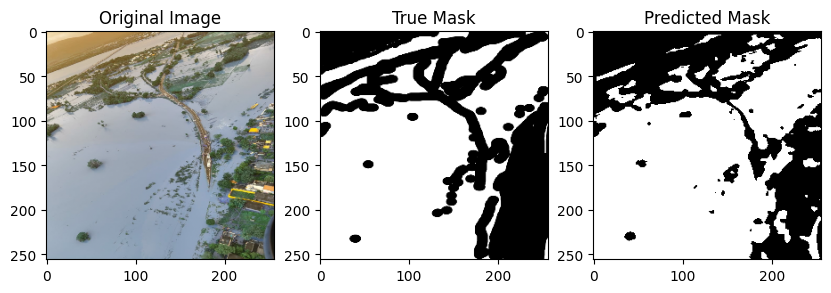

1/1 [==============================] - 0s 20ms/step


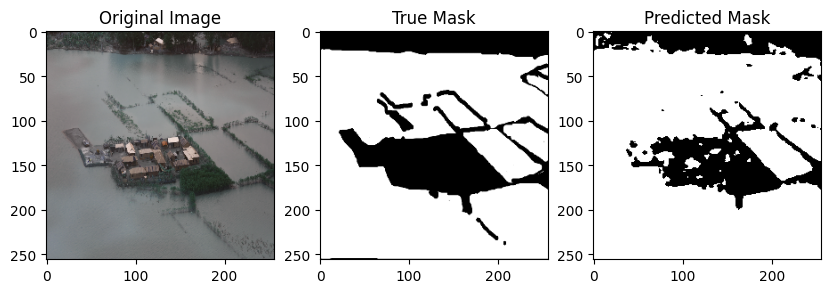

1/1 [==============================] - 0s 21ms/step


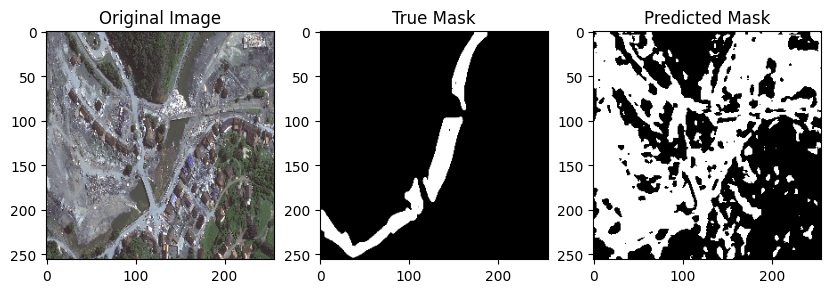

In [5]:


# Visualize some predictions
def display_predictions(model, X_test, y_test, index):
    predicted_mask = model.predict(np.expand_dims(X_test[index], axis=0))
    predicted_mask = (predicted_mask > 0.5).astype(np.uint8)
    
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 3, 1)
    plt.title("Original Image")
    plt.imshow(X_test[index])

    plt.subplot(1, 3, 2)
    plt.title("True Mask")
    plt.imshow(y_test[index], cmap='gray')

    plt.subplot(1, 3, 3)
    plt.title("Predicted Mask")
    plt.imshow(predicted_mask[0], cmap='gray')

    plt.show()

# Display predictions for the first 5 test images
for i in range(5):
    display_predictions(model, X_test, y_test, i)


In [6]:
model.save('flood_segmentation_model2.h5')

In [7]:
import tensorflow as tf

# Function to load the model
def load_segmentation_model():
    model_path = r"C:\Users\jash1\OneDrive\Desktop\sem 7\dl_app\image_segmentation\flood_segmentation_model1.h5"
    model = tf.keras.models.load_model(model_path)
    print("Model loaded successfully!")
    return model

# Load the model
model = load_segmentation_model()


Model loaded successfully!
